<a href="https://colab.research.google.com/github/GabrielAzqe/Modelo-de-Preven-o-a-Fraudes/blob/main/Modelo_de_Preven%C3%A7%C3%A3o_a_Fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Detecção de Fraudes em Transações

In [1]:
import pandas as pd
import numpy as np

##Problema de Classificação desbalanceada


- Fraudes são Raras -> Modelo pode ignorar a classe 1

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


#Problema de classificação desbalanceada


In [3]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


#Feature Engineering

-Criação de Variaveis que ajudam o Modelo

In [4]:
df['Amoount_log'] = np.log1p(df["Amount"]) # nornamilização de valores para facilitar processo de aprendizado do modelo



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amoount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0,1.541159
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0,1.790091
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0,3.732896
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0,4.545420
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0,1.543298


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Padronizando escala unica dos dados

df['Amoount_scaled'] = scaler.fit_transform(df[['Amount']])

In [10]:
from  sklearn.model_selection import train_test_split

x = df.drop("Class", axis = 1)
y = df['Class'] # Coluna de Verificação

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) #Divisão de Dados em treino e teste nessa divisão usaremos 30% pra teste e 70% validação
#

#Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred)) # mesmo acurancia sendo alta devemos usar o recal para verificação de falsos possitivos

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.83      0.63      0.72       136

    accuracy                           1.00     85443
   macro avg       0.92      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



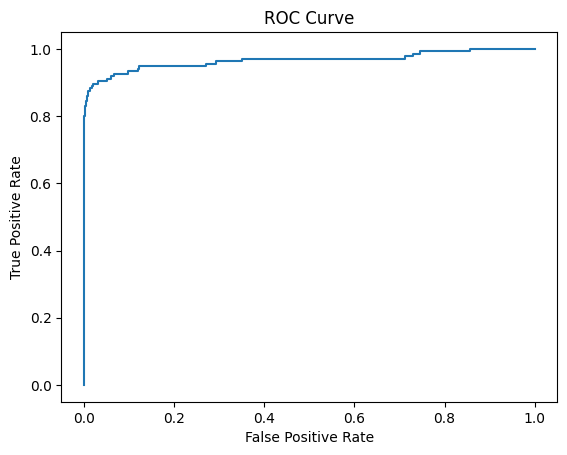

AUC:  0.9659766042232242


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs))
#

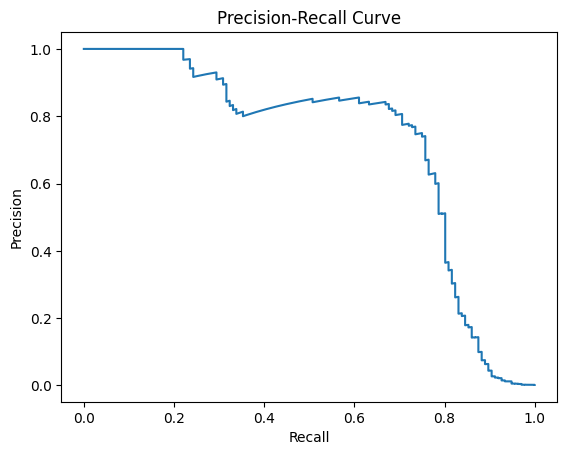

In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall") # Modelo Conservador
plt.ylabel("Precision") # Muitos Falsos Positivos
plt.show()

#Balanceado os dados

In [21]:
#Undersampling
fraudes = df[df['Class'] == 1] #Equalizando numero de Amostras de Fraude e Não Fraude
normais = df[df['Class'] == 0].sample(n=len(fraudes), random_state=42)

df_undersampled = pd.concat([fraudes, normais])

In [22]:
#Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE() # Projetando Dados para uma amostra maior durante  a analise

x_res, y_res = smote.fit_resample(x, y)


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 50,#Numero de Arvores de Decisão
    max_depth = 10, #Limitação de Profundidade de Arvores
    random_state = 42,
    class_weight = 'balanced', # Dando importancia pra Fraudes
    n_jobs = -1
)

rf.fit(x_res, y_res)

y_pred = rf.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.59      0.96      0.73       136

    accuracy                           1.00     85443
   macro avg       0.79      0.98      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [26]:
from sklearn.pipeline import Pipeline


pipeline = Pipeline ([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter = 1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)



In [27]:
threshold = 0.3 # probabilidade de ser uma Fraude
y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.82      0.68      0.74       136

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



#Modelo Acançado XGBC BOST

- Algoritmo mais usado que consiste em processamento de arvores sequenciais para toma de decisão

In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = 10, # balanceamento
    use_label_encoder = False,
    eval_metric = 'logloss',
)

xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

y_prod_xgb = xgb.predict(x_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:24:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.94      0.85      0.90       136

    accuracy                           1.00     85443
   macro avg       0.97      0.93      0.95     85443
weighted avg       1.00      1.00      1.00     85443



#Importancia de Variaveis

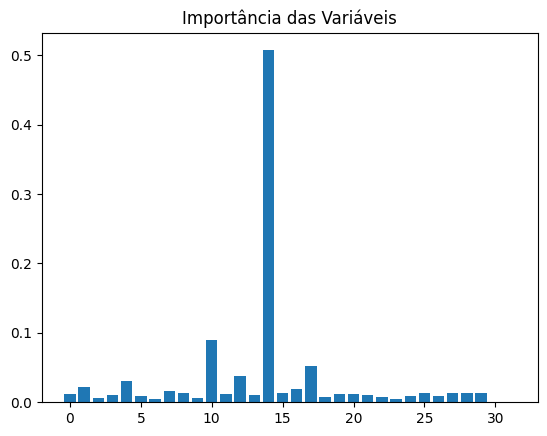

In [31]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis") # Pesso na tomada de decissão da Fraude
plt.show()

#Ajuste de Hiperparametros

- Ajuste de melhores combinações de otimização do modelo

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_deth" : [3,5],
    "n_estimators" : [50,100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric = 'logloss'),
    param_grid,
    scoring = "recall",
    cv = 3
)

grid.fit(x_train, y_train)

print("Melhor modelo",grid.best_params_)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_deth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_deth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_deth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_deth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:51] WARNING

Melhor modelo {'max_deth': 3, 'n_estimators': 100}


#Explicabilidade (Shap)

-Shap Mostra como cada variavel infleuncia a decissão do Modelo

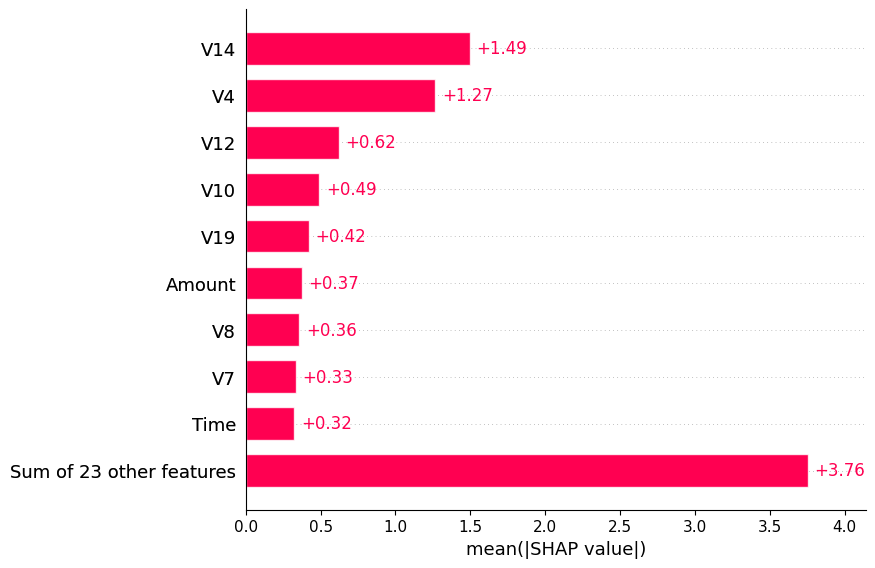

In [44]:
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])
shap.plots.bar(shap_values)